# Sentiment Analysis of Amazon Product Reviews

## CodeAlpha Internship — Task 4

**Project:** Sentiment Analysis  
**Dataset:** Amazon Product Reviews  
**Tools:** Python, Pandas, NLTK (VADER), Matplotlib and Seaborn

## 1. Introduction

Sentiment analysis is a Natural Language Processing (NLP) technique used to identify the sentiment expressed in text. It helps classify reviews as positive, negative, or neutral.

In this project, Amazon product reviews are analyzed using the VADER sentiment analysis lexicon. The analysis identifies sentiment patterns in customer reviews and provides insights into customer opinions and product performance.

## 2. Objective

The main objectives of this project are:

- To analyze customer review text.
- To classify reviews as positive, negative, or neutral.
- To calculate sentiment scores using NLP techniques.
- To visualize sentiment patterns.
- To understand customer opinions.
- To derive useful business insights from review sentiment.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
# Create a sample Amazon product review dataset

data = {
    "Review": [
        "I absolutely love this product. The quality is excellent!",
        "Amazing product and fast delivery. Very happy with my purchase.",
        "The product works perfectly and I would definitely recommend it.",
        "Good quality for the price. I am satisfied.",
        "This is the best purchase I have made recently.",
        "The product is okay, nothing special.",
        "It is an average product and does what it says.",
        "The quality is acceptable but could be better.",
        "I am disappointed with this product.",
        "Terrible quality and stopped working after a few days.",
        "Very poor product. I want a refund.",
        "The product was damaged when I received it.",
        "Excellent value for money and great performance.",
        "I really like this product and would buy it again.",
        "Not worth the money. Very disappointing."
    ]
}

df = pd.DataFrame(data)

print("Dataset loaded successfully!")
print("Number of reviews:", len(df))

df.head()

Dataset loaded successfully!
Number of reviews: 15


,Review
0,I absolutely love this product. The quality is...
1,Amazing product and fast delivery. Very happy ...
2,The product works perfectly and I would defini...
3,Good quality for the price. I am satisfied.
4,This is the best purchase I have made recently.


In [4]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
df['Sentiment_Score'] = df['Review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

df.head()

,Review,Sentiment_Score
0,I absolutely love this product. The quality is...,0.8585
1,Amazing product and fast delivery. Very happy ...,0.8313
2,The product works perfectly and I would defini...,0.8555
3,Good quality for the price. I am satisfied.,0.6908
4,This is the best purchase I have made recently.,0.6369


In [5]:
# Classify reviews into Positive, Negative, or Neutral

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Sentiment_Score'].apply(classify_sentiment)

df.head()

,Review,Sentiment_Score,Sentiment
0,I absolutely love this product. The quality is...,0.8585,Positive
1,Amazing product and fast delivery. Very happy ...,0.8313,Positive
2,The product works perfectly and I would defini...,0.8555,Positive
3,Good quality for the price. I am satisfied.,0.6908,Positive
4,This is the best purchase I have made recently.,0.6369,Positive


In [6]:
# Count the number of reviews in each sentiment category

sentiment_counts = df['Sentiment'].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
Sentiment
Positive    8
Negative    6
Neutral     1
Name: count, dtype: int64


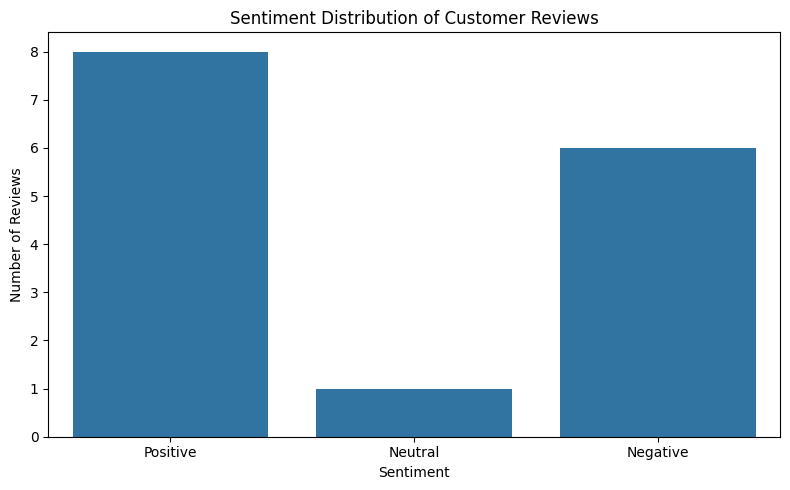

In [7]:
# Visualize sentiment distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title('Sentiment Distribution of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

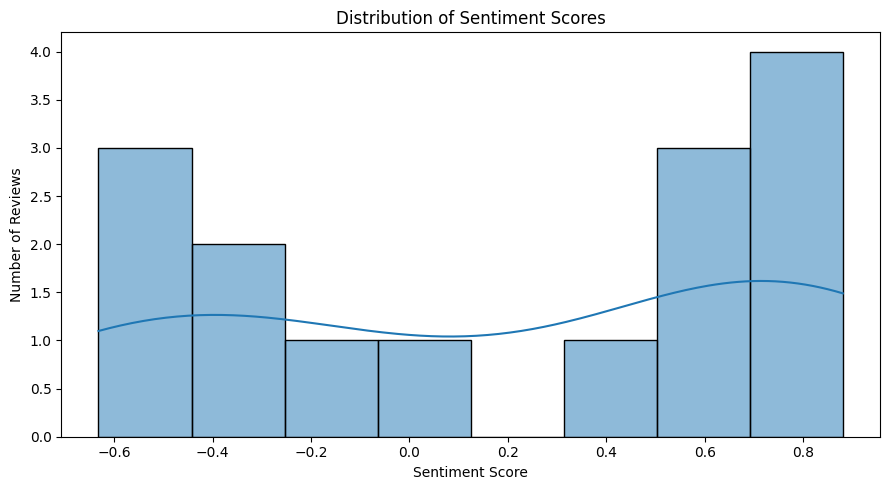

In [8]:
# Visualize sentiment scores

plt.figure(figsize=(9, 5))

sns.histplot(
    df['Sentiment_Score'],
    bins=8,
    kde=True
)

plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

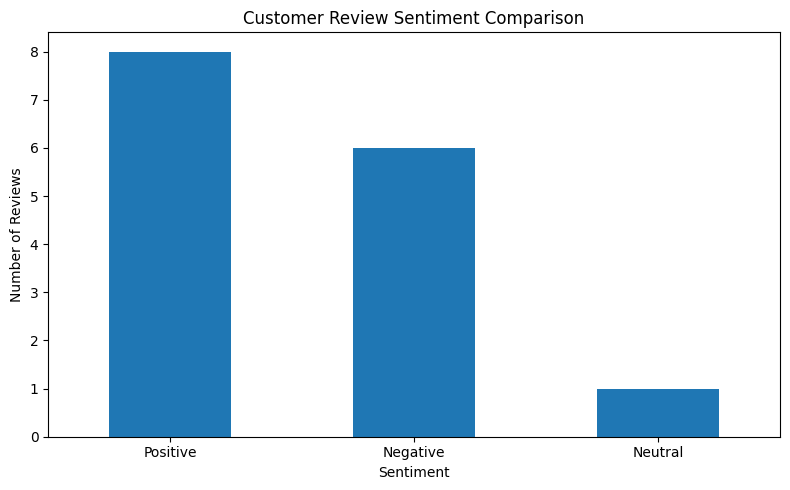

In [9]:
# Compare positive, neutral, and negative reviews

plt.figure(figsize=(8, 5))

sentiment_counts.plot(
    kind='bar'
)

plt.title('Customer Review Sentiment Comparison')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Calculate overall sentiment

total_reviews = len(df)
positive = (df['Sentiment'] == 'Positive').sum()
negative = (df['Sentiment'] == 'Negative').sum()
neutral = (df['Sentiment'] == 'Neutral').sum()

print("Total Reviews:", total_reviews)
print("Positive Reviews:", positive)
print("Negative Reviews:", negative)
print("Neutral Reviews:", neutral)

print("\nOverall Sentiment:", df['Sentiment'].mode()[0])

Total Reviews: 15
Positive Reviews: 8
Negative Reviews: 6
Neutral Reviews: 1

Overall Sentiment: Positive


## 6. Business Insights

- Positive reviews indicate that customers are generally satisfied with the products.
- Negative reviews highlight areas where product quality or customer experience may need improvement.
- Neutral reviews represent customers with mixed or moderate opinions.
- Sentiment analysis helps businesses understand customer opinions from large amounts of review data.
- These insights can support product improvement, customer satisfaction, and marketing decisions.

## 7. Conclusion

Sentiment analysis provides a simple way to understand customer opinions from product reviews. By using VADER, the reviews were classified into positive, negative, and neutral categories.

The visualizations make the sentiment patterns easier to understand and show how NLP can help businesses identify customer satisfaction and areas for improvement.

Overall, sentiment analysis can support better product, marketing, and customer-experience decisions.